       coin symbol         price     1h    24h     7d    24h_volume  \
0   Bitcoin    BTC  40851.380000  0.001  0.000 -0.027  2.047612e+10   
1  Ethereum    ETH   2824.420000  0.004  0.029  0.034  1.364041e+10   
2    Tether   USDT      1.000000 -0.000  0.000  0.000  4.413140e+10   
3       BNB    BNB    389.610000  0.002  0.016 -0.010  1.425354e+09   
4  USD Coin   USDC      0.999739 -0.001  0.000 -0.000  3.569816e+09   

        mkt_cap        date  
0  7.760774e+11  2022-03-17  
1  3.390772e+11  2022-03-17  
2  8.020588e+10  2022-03-17  
3  6.556116e+10  2022-03-17  
4  5.259607e+10  2022-03-17  
Index(['coin', 'symbol', 'price', '1h', '24h', '7d', '24h_volume', 'mkt_cap',
       'date'],
      dtype='object')
MAE = 578914153.3715858
RMSE = 4270299707.8386307
R2 Score = 0.21699688340501433


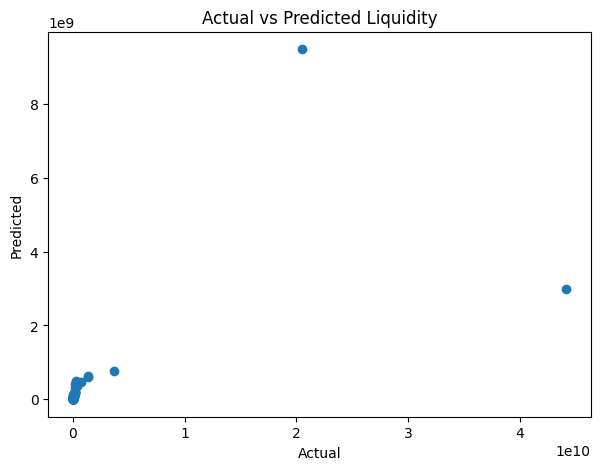

In [3]:
# Corrected Cryptocurrency Liquidity Prediction Project Code

# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# 2. Upload CSV in Colab first
# Then run this
# ===============================
df = pd.read_csv('/content/coin_gecko_2022-03-17.csv')

print(df.head())

# ===============================
# 3. Clean Column Names
# ===============================
df.columns = df.columns.str.strip()

print(df.columns)

# ===============================
# 4. Missing Values
# ===============================
df = df.fillna(0)

# ===============================
# 5. Feature Engineering
# ===============================
df["price_volatility"] = abs(df["24h"])
df["liquidity_ratio"] = df["24h_volume"] / (df["mkt_cap"] + 1)

# ===============================
# 6. Input and Output
# ===============================
X = df[["price", "1h", "24h", "7d", "mkt_cap",
        "price_volatility", "liquidity_ratio"]]

y = df["24h_volume"]

# ===============================
# 7. Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 8. Scaling
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 9. Train Model
# ===============================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ===============================
# 10. Prediction
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 11. Results
# ===============================
print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score =", r2_score(y_test, y_pred))

# ===============================
# 12. Plot
# ===============================
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Liquidity")
plt.show()